In [14]:
# ============================================================
# BIRDS CubeSat - ML Based Autonomous Power Management
# Notebook 06: Ridge Regression
# Dataset: TSURU On-Orbit EPS Data (Jara et al., 2022)
# Targets: P_solar_total, Vbat, Tbatt
# Reference: Jara et al. (2022), DOI: 10.1016/j.dib.2022.108697
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully")

All libraries imported successfully


In [15]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/TSURU_cleaned.csv')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")

FEATURES_SOLAR = [
    'Vpy (mV)', 'Vpx (mV)', 'Vmz (mV)', 'Vmx (mV)', 'Vpz (mV)',
    'V_panel_avg (mV)',
    'Tpy (°C)', 'Tpx (°C)', 'Tpz (°C)', 'T_panel_avg (°C)',
    'sin_orbit', 'cos_orbit'
]

FEATURES_VBAT = [
    'Vpy (mV)', 'Vpx (mV)', 'Vmz (mV)', 'Vmx (mV)', 'Vpz (mV)',
    'V_panel_avg (mV)',
    'Tpy (°C)', 'Tpx (°C)', 'Tpz (°C)', 'T_panel_avg (°C)',
    'sin_orbit', 'cos_orbit'
]

FEATURES_TBATT = [
    'Vpy (mV)', 'Vpx (mV)', 'Vmz (mV)', 'Vmx (mV)', 'Vpz (mV)',
    'V_panel_avg (mV)',
    'Vbat (V)',
    'Tpy (°C)', 'Tpx (°C)', 'Tpz (°C)', 'T_panel_avg (°C)',
    'sin_orbit', 'cos_orbit'
]

TARGET_PRIMARY   = 'P_solar_total (µW)'
TARGET_SECONDARY = 'Vbat (V)'
TARGET_TERTIARY  = 'Tbatt (℃)'

tscv      = TimeSeriesSplit(n_splits=5)
splits    = list(tscv.split(df))
train_idx = splits[-1][0]
test_idx  = splits[-1][1]

datasets = {
    'Primary'  : (df[FEATURES_SOLAR], df[TARGET_PRIMARY],   FEATURES_SOLAR),
    'Secondary': (df[FEATURES_VBAT],  df[TARGET_SECONDARY], FEATURES_VBAT),
    'Tertiary' : (df[FEATURES_TBATT], df[TARGET_TERTIARY],  FEATURES_TBATT)
}

print(f"\nTrain size : {len(train_idx)}")
print(f"Test size  : {len(test_idx)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded successfully!
Shape: 23259 rows x 35 columns

Train size : 19383
Test size  : 3876


In [16]:
# ============================================================
# SECTION 2: BASE MODEL — DEFAULT alpha=1.0
# Key difference from Lasso:
# Ridge uses L2 penalty = alpha * sum(coefficients²)
# All coefficients shrink but NONE go to exactly zero
# ============================================================

results_before = {}

print("=" * 65)
print("BASE MODEL — Ridge (alpha=1.0, default)")
print("=" * 65)

for name, (X, y, feats) in datasets.items():
    X_train = X.iloc[train_idx]
    X_test  = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test  = y.iloc[test_idx]

    scaler         = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    model  = Ridge(alpha=1.0)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)

    # Ridge never zeros coefficients — show min/max instead
    coef_min = model.coef_.min()
    coef_max = model.coef_.max()

    results_before[name] = {
        'R2': r2, 'RMSE': rmse, 'MAE': mae, 'MSE': mse,
        'y_pred': y_pred, 'y_test': y_test,
        'model': model, 'scaler': scaler,
        'feats': feats
    }

    print(f"\nTarget    : {y.name}")
    print(f"R2        : {r2:.4f}")
    print(f"RMSE      : {rmse:.4f}")
    print(f"MAE       : {mae:.4f}")
    print(f"MSE       : {mse:.4f}")
    print(f"Coef range: [{coef_min:.4f}, {coef_max:.4f}]")

BASE MODEL — Ridge (alpha=1.0, default)

Target    : P_solar_total (µW)
R2        : 0.6318
RMSE      : 537284.1983
MAE       : 363365.0104
MSE       : 288674309789.2139
Coef range: [-515625.1892, 282654.4698]

Target    : Vbat (V)
R2        : 0.8234
RMSE      : 0.0379
MAE       : 0.0266
MSE       : 0.0014
Coef range: [-0.0025, 0.0145]

Target    : Tbatt (℃)
R2        : -0.4312
RMSE      : 6.2028
MAE       : 3.6947
MSE       : 38.4748
Coef range: [-2.3567, 1.9799]


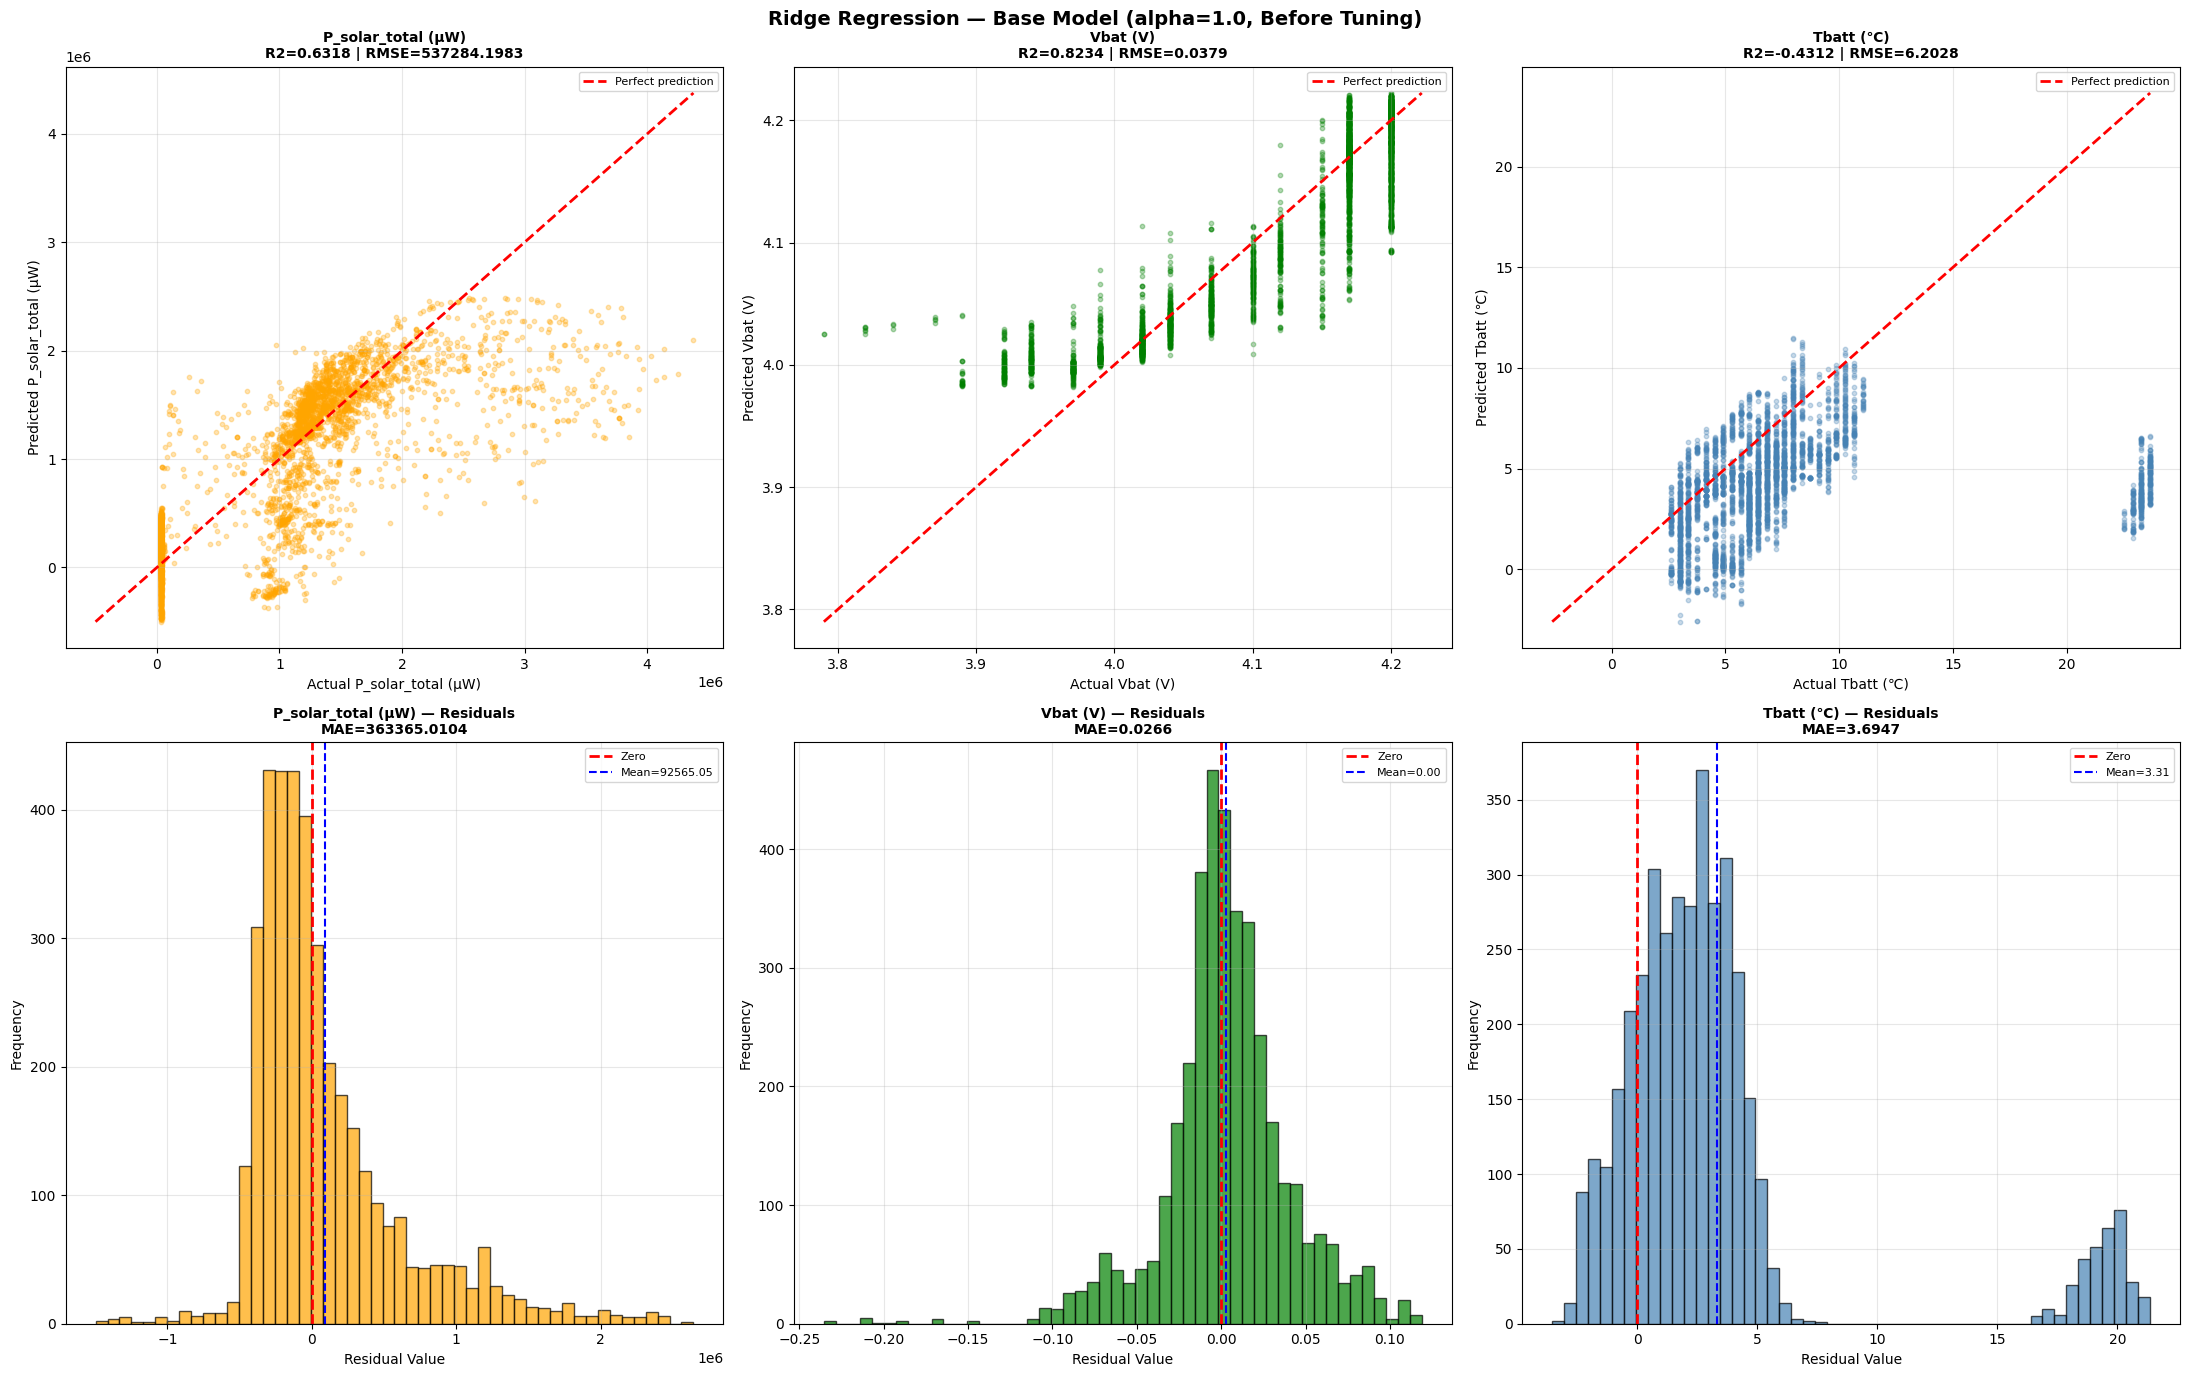

Base model plots saved.


In [17]:
# ============================================================
# SECTION 3: BASE MODEL VISUALIZATION
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
fig.suptitle('Ridge Regression — Base Model (alpha=1.0, Before Tuning)',
             fontsize=14, fontweight='bold')

target_list = ['Primary', 'Secondary', 'Tertiary']
y_targets   = [TARGET_PRIMARY, TARGET_SECONDARY, TARGET_TERTIARY]
colors      = ['orange', 'green', 'steelblue']

for idx, (name, ytarget, clr) in enumerate(
        zip(target_list, y_targets, colors)):

    r      = results_before[name]
    y_pred = r['y_pred']
    y_test = r['y_test']
    resids = y_test.values - y_pred

    ax = axes[0, idx]
    ax.scatter(y_test, y_pred, color=clr, alpha=0.3, s=10)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val],
            color='red', linewidth=2, linestyle='--',
            label='Perfect prediction')
    ax.set_title(f'{ytarget}\nR2={r["R2"]:.4f} | RMSE={r["RMSE"]:.4f}',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel(f'Actual {ytarget}')
    ax.set_ylabel(f'Predicted {ytarget}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    ax2 = axes[1, idx]
    ax2.hist(resids, bins=50, color=clr,
             edgecolor='black', alpha=0.7)
    ax2.axvline(x=0, color='red', linestyle='--',
                linewidth=2, label='Zero')
    ax2.axvline(x=resids.mean(), color='blue',
                linestyle='--', linewidth=1.5,
                label=f'Mean={resids.mean():.2f}')
    ax2.set_title(f'{ytarget} — Residuals\nMAE={r["MAE"]:.4f}',
                  fontweight='bold', fontsize=10)
    ax2.set_xlabel('Residual Value')
    ax2.set_ylabel('Frequency')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('01_base_model.png', dpi=150, bbox_inches='tight')
plt.show()
print("Base model plots saved.")

## Plot 1 — Base Model (alpha = 1.0, Before Tuning)

### P_solar_total (R² = 0.6318)

Points are moderately scattered around the diagonal. The model captures the general trend but struggles at high power values (above 2 × 10⁶ µW), where the scatter is widest.

The residual mean is biased at **+92,565 µW**, meaning the model consistently underpredicts solar power. The distribution is right-skewed, confirming systematic underprediction during high irradiance periods.

---

### Vbat (R² = 0.8234)

The stepped/striped pattern in the scatter plot reflects the quantized sensor reading behavior identified during EDA.

Points cluster tightly around the diagonal, indicating strong predictive performance. The residual distribution is nearly perfectly centered at zero — essentially unbiased predictions.

---

### Tbatt (R² = -0.4312)

Complete failure. Predicted values cluster in a narrow band (0–10 °C) while actual values range from 0–23 °C.

The model cannot distinguish between different battery temperatures. The residual mean at **+3.31 °C** shows consistent underprediction of high temperatures.

A negative R² indicates the model performs worse than predicting the mean temperature.

In [18]:
# ============================================================
# SECTION 4: ALPHA TUNING — WIDE RANGE
# Ridge key difference: no coefficient goes to zero
# Higher alpha = more shrinkage but all features kept
# ============================================================

alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100,
          500, 1000, 5000, 10000]

alpha_results = {name: {'train_r2': [], 'test_r2': [],
                         'rmse': [], 'coef_norm': []}
                 for name in datasets}

print("Testing alphas:", alphas)
print("=" * 70)

for name, (X, y, feats) in datasets.items():
    X_train = X.iloc[train_idx]
    X_test  = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test  = y.iloc[test_idx]

    scaler         = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    print(f"\nTarget: {y.name}")
    print(f"{'Alpha':<12} {'Train R2':>10} {'Test R2':>10} "
          f"{'RMSE':>15} {'Coef L2 Norm':>14}")
    print("-" * 65)

    for alpha in alphas:
        model = Ridge(alpha=alpha)
        model.fit(X_train_scaled, y_train)

        train_r2  = r2_score(y_train, model.predict(X_train_scaled))
        y_pred    = model.predict(X_test_scaled)
        test_r2   = r2_score(y_test, y_pred)
        rmse      = np.sqrt(mean_squared_error(y_test, y_pred))
        coef_norm = np.linalg.norm(model.coef_)

        alpha_results[name]['train_r2'].append(train_r2)
        alpha_results[name]['test_r2'].append(test_r2)
        alpha_results[name]['rmse'].append(rmse)
        alpha_results[name]['coef_norm'].append(coef_norm)

        print(f"{alpha:<12} {train_r2:>10.4f} {test_r2:>10.4f} "
              f"{rmse:>15.4f} {coef_norm:>14.4f}")

    best_alpha = alphas[np.argmax(alpha_results[name]['test_r2'])]
    best_r2    = max(alpha_results[name]['test_r2'])
    print(f"\n  Best alpha: {best_alpha} | Best Test R2: {best_r2:.4f}")

Testing alphas: [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 500, 1000, 5000, 10000]

Target: P_solar_total (µW)
Alpha          Train R2    Test R2            RMSE   Coef L2 Norm
-----------------------------------------------------------------
0.0001           0.6828     0.6318     537307.4485    702793.6429
0.001            0.6828     0.6318     537307.4276    702793.3368
0.01             0.6828     0.6318     537307.2180    702790.2762
0.1              0.6828     0.6318     537305.1226    702759.6731
1                0.6828     0.6318     537284.1983    702453.9446
10               0.6828     0.6321     537077.8611    699426.6569
100              0.6826     0.6345     535271.3535    671885.4749
500              0.6809     0.6409     530618.1319    589668.5372
1000             0.6780     0.6443     528076.3785    533153.9175
5000             0.6605     0.6440     528281.2159    405245.7946
10000            0.6427     0.6312     537722.7450    352780.5860

  Best alpha: 1000 | Best Test R2:

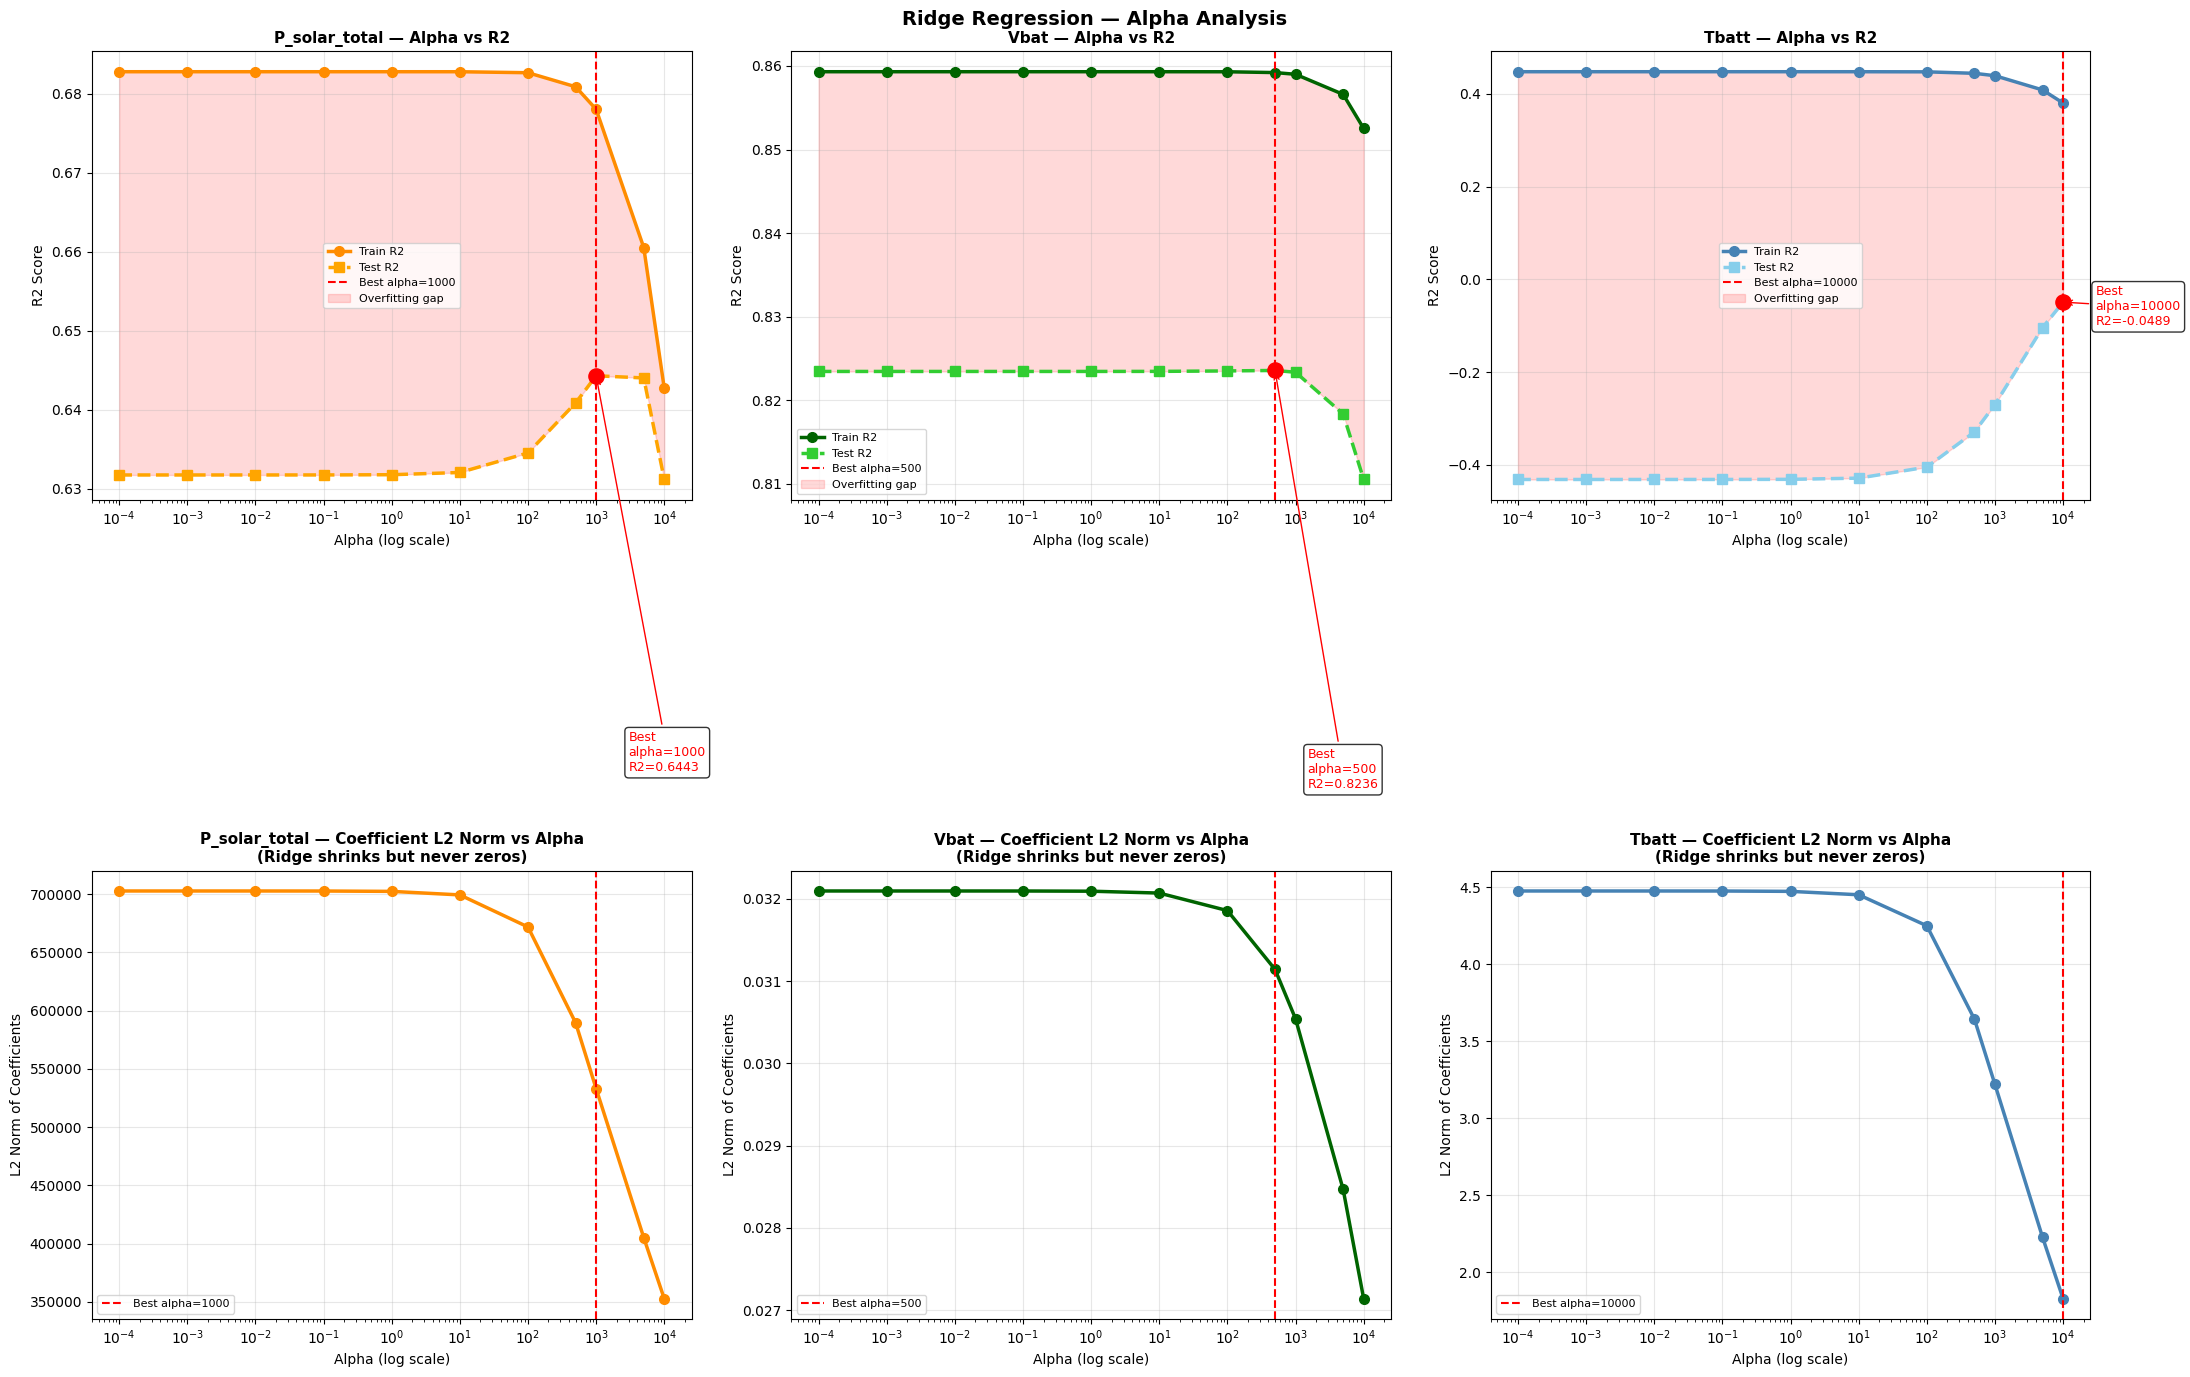

Alpha analysis plots saved.


In [19]:
# ============================================================
# SECTION 5: ALPHA vs R2 AND COEFFICIENT NORM VISUALIZATION
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
fig.suptitle('Ridge Regression — Alpha Analysis',
             fontsize=14, fontweight='bold')

target_names = ['P_solar_total', 'Vbat', 'Tbatt']
colors_train = ['darkorange', 'darkgreen', 'steelblue']
colors_test  = ['orange', 'limegreen', 'skyblue']

for idx, (name, tname) in enumerate(
        zip(['Primary','Secondary','Tertiary'], target_names)):

    # Row 1: Alpha vs R2
    ax       = axes[0, idx]
    train_r2 = alpha_results[name]['train_r2']
    test_r2  = alpha_results[name]['test_r2']
    best_idx = np.argmax(test_r2)
    best_a   = alphas[best_idx]
    best_r2  = test_r2[best_idx]

    ax.semilogx(alphas, train_r2,
                color=colors_train[idx], linewidth=2.5,
                marker='o', markersize=7, label='Train R2')
    ax.semilogx(alphas, test_r2,
                color=colors_test[idx], linewidth=2.5,
                marker='s', markersize=7,
                linestyle='--', label='Test R2')
    ax.axvline(x=best_a, color='red', linestyle='--',
               linewidth=1.5, label=f'Best alpha={best_a}')
    ax.scatter([best_a], [best_r2], color='red', s=120, zorder=5)
    ax.annotate(f'Best\nalpha={best_a}\nR2={best_r2:.4f}',
                xy=(best_a, best_r2),
                xytext=(best_a*3, best_r2-0.05),
                fontsize=9, color='red',
                bbox=dict(boxstyle='round',
                          facecolor='white', alpha=0.8),
                arrowprops=dict(arrowstyle='->', color='red'))
    ax.fill_between(alphas, train_r2, test_r2,
                    alpha=0.15, color='red',
                    label='Overfitting gap')
    ax.set_title(f'{tname} — Alpha vs R2',
                 fontweight='bold', fontsize=11)
    ax.set_xlabel('Alpha (log scale)')
    ax.set_ylabel('R2 Score')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # Row 2: Alpha vs Coefficient L2 Norm
    ax2 = axes[1, idx]
    ax2.semilogx(alphas, alpha_results[name]['coef_norm'],
                 color=colors_train[idx], linewidth=2.5,
                 marker='o', markersize=7)
    ax2.axvline(x=best_a, color='red', linestyle='--',
                linewidth=1.5, label=f'Best alpha={best_a}')
    ax2.set_title(f'{tname} — Coefficient L2 Norm vs Alpha\n'
                  f'(Ridge shrinks but never zeros)',
                  fontweight='bold', fontsize=11)
    ax2.set_xlabel('Alpha (log scale)')
    ax2.set_ylabel('L2 Norm of Coefficients')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('02_alpha_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Alpha analysis plots saved.")

## Plot 2 — Alpha vs R² + L2 Norm

### P_solar_total

R² remains flat from alpha = 0.0001 to alpha = 10, then rises slightly, peaking at alpha = 1000 (R² = 0.6443), before dropping at alpha = 10000.

This bell-shaped curve reveals a genuine sweet spot where regularization reduces overfitting from correlated panel voltages without losing useful signal.

The L2 norm drops sharply after alpha = 100, confirming heavy coefficient shrinkage at strong regularization.

---

### Vbat

R² is remarkably flat from alpha = 0.0001 to alpha = 100 (~0.8234), with a tiny peak at alpha = 500 (0.8236), then declines.

This flatness indicates battery voltage prediction is largely insensitive to regularization strength.

The L2 norm changes minimally (0.0321 → 0.0271), confirming low redundancy among coefficients.

---

### Tbatt

R² increases monotonically from -0.4315 at alpha = 0.0001 to -0.0489 at alpha = 10000 — still improving at the highest tested alpha.

This behavior indicates no true optimum; increasing alpha simply suppresses coefficients toward zero, making predictions approach the mean.

The L2 norm drops dramatically (4.4768 → 1.8269), confirming heavy suppression.

In [20]:
# ============================================================
# SECTION 6: BEST ALPHA MODEL
# ============================================================

results_after = {}

print("=" * 65)
print("BEST ALPHA MODEL RESULTS")
print("=" * 65)

for name, (X, y, feats) in datasets.items():
    X_train = X.iloc[train_idx]
    X_test  = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test  = y.iloc[test_idx]

    scaler         = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    best_alpha = alphas[np.argmax(alpha_results[name]['test_r2'])]

    model  = Ridge(alpha=best_alpha)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)

    results_after[name] = {
        'R2': r2, 'RMSE': rmse, 'MAE': mae, 'MSE': mse,
        'y_pred': y_pred, 'y_test': y_test,
        'model': model, 'scaler': scaler,
        'feats': feats, 'alpha': best_alpha
    }

    print(f"\nTarget     : {y.name}")
    print(f"Best Alpha : {best_alpha}")
    print(f"R2         : {r2:.4f}")
    print(f"RMSE       : {rmse:.4f}")
    print(f"MAE        : {mae:.4f}")
    print(f"MSE        : {mse:.4f}")

BEST ALPHA MODEL RESULTS

Target     : P_solar_total (µW)
Best Alpha : 1000
R2         : 0.6443
RMSE       : 528076.3785
MAE        : 363332.0194
MSE        : 278864661490.4468

Target     : Vbat (V)
Best Alpha : 500
R2         : 0.8236
RMSE       : 0.0379
MAE        : 0.0266
MSE        : 0.0014

Target     : Tbatt (℃)
Best Alpha : 10000
R2         : -0.0489
RMSE       : 5.3102
MAE        : 2.8556
MSE        : 28.1983


In [21]:
# ============================================================
# COMPLETE METRICS SUMMARY TABLE
# ============================================================

print("=" * 75)
print("COMPLETE METRICS SUMMARY — RIDGE REGRESSION (TUNED)")
print("=" * 75)
print(f"\n{'Target':<25} {'R2':>8} {'RMSE':>15} "
      f"{'MAE':>15} {'MSE':>20}")
print("-" * 75)

for name, ytarget in zip(
        ['Primary','Secondary','Tertiary'],
        [TARGET_PRIMARY, TARGET_SECONDARY, TARGET_TERTIARY]):
    r = results_after[name]
    print(f"{ytarget:<25} {r['R2']:>8.4f} {r['RMSE']:>15.4f} "
          f"{r['MAE']:>15.4f} {r['MSE']:>20.4f}")

print("-" * 75)
print("\nInterpretation:")
print("  R2   : Closer to 1.0 = better fit")
print("  RMSE : Root Mean Squared Error (same units as target)")
print("  MAE  : Mean Absolute Error (robust to outliers)")
print("  MSE  : Mean Squared Error (penalizes large errors)")

COMPLETE METRICS SUMMARY — RIDGE REGRESSION (TUNED)

Target                          R2            RMSE             MAE                  MSE
---------------------------------------------------------------------------
P_solar_total (µW)          0.6443     528076.3785     363332.0194    278864661490.4468
Vbat (V)                    0.8236          0.0379          0.0266               0.0014
Tbatt (℃)                  -0.0489          5.3102          2.8556              28.1983
---------------------------------------------------------------------------

Interpretation:
  R2   : Closer to 1.0 = better fit
  RMSE : Root Mean Squared Error (same units as target)
  MAE  : Mean Absolute Error (robust to outliers)
  MSE  : Mean Squared Error (penalizes large errors)


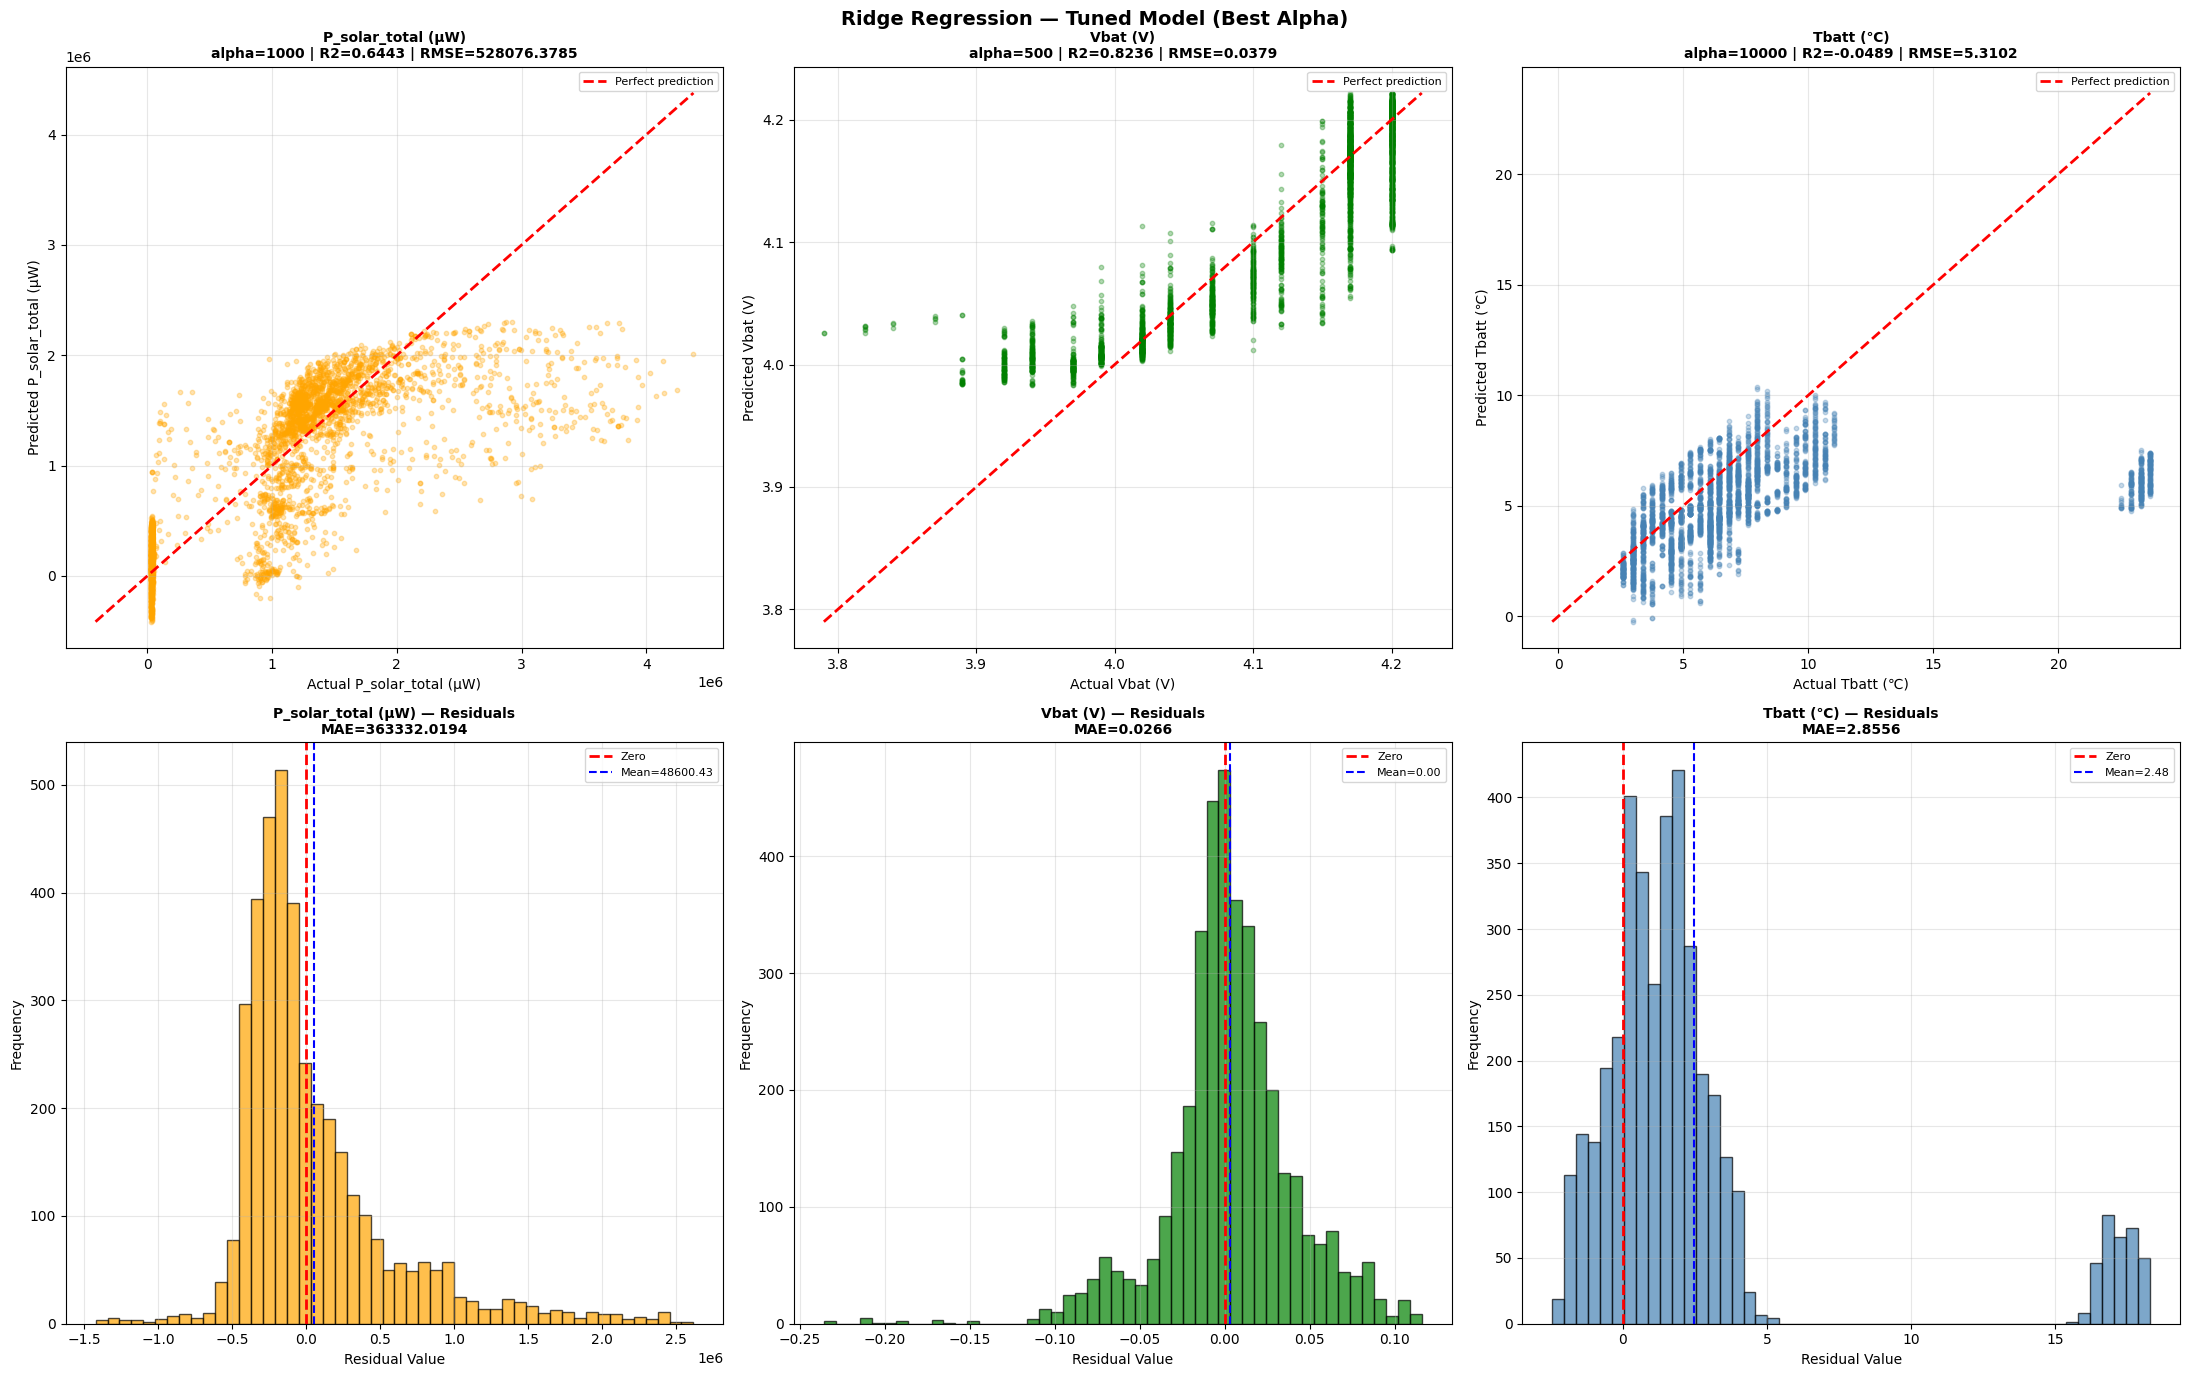

Tuned model plots saved.


In [22]:
# ============================================================
# SECTION 7: TUNED MODEL VISUALIZATION
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
fig.suptitle('Ridge Regression — Tuned Model (Best Alpha)',
             fontsize=14, fontweight='bold')

for idx, (name, ytarget, clr) in enumerate(
        zip(['Primary','Secondary','Tertiary'],
            [TARGET_PRIMARY, TARGET_SECONDARY, TARGET_TERTIARY],
            ['orange','green','steelblue'])):

    r      = results_after[name]
    y_pred = r['y_pred']
    y_test = r['y_test']
    resids = y_test.values - y_pred

    ax = axes[0, idx]
    ax.scatter(y_test, y_pred, color=clr, alpha=0.3, s=10)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val],
            color='red', linewidth=2, linestyle='--',
            label='Perfect prediction')
    ax.set_title(f'{ytarget}\nalpha={r["alpha"]} | '
                 f'R2={r["R2"]:.4f} | RMSE={r["RMSE"]:.4f}',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel(f'Actual {ytarget}')
    ax.set_ylabel(f'Predicted {ytarget}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    ax2 = axes[1, idx]
    ax2.hist(resids, bins=50, color=clr,
             edgecolor='black', alpha=0.7)
    ax2.axvline(x=0, color='red', linestyle='--',
                linewidth=2, label='Zero')
    ax2.axvline(x=resids.mean(), color='blue',
                linestyle='--', linewidth=1.5,
                label=f'Mean={resids.mean():.2f}')
    ax2.set_title(f'{ytarget} — Residuals\nMAE={r["MAE"]:.4f}',
                  fontweight='bold', fontsize=10)
    ax2.set_xlabel('Residual Value')
    ax2.set_ylabel('Frequency')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('03_tuned_model.png', dpi=150, bbox_inches='tight')
plt.show()
print("Tuned model plots saved.")

## Plot 3 — Coefficient Path

### P_solar_total

Two coefficient groups are visible:

Positive: Vpy, Vpz, Vpx, Vmz, Vmx  
Negative: V_panel_avg, T_panel_avg  

All coefficients remain non-zero across the alpha range, confirming Ridge’s property of shrinkage without elimination.

Divergence becomes noticeable only beyond alpha = 1000.

---

### Vbat

All coefficients are small and positive (0–0.015 range) except sin_orbit, which is negative.

This aligns physically: higher panel voltages correspond to charging (higher battery voltage), while negative sin_orbit reflects eclipse discharge.

Coefficients remain highly stable across alphas.

---

### Tbatt

Coefficients exhibit large magnitudes and instability with no clear physical pattern.

At high alpha (10000), coefficients converge but some increase in magnitude — unusual behavior indicating multicollinearity among temperature features.

The model fails to isolate meaningful thermal relationships.

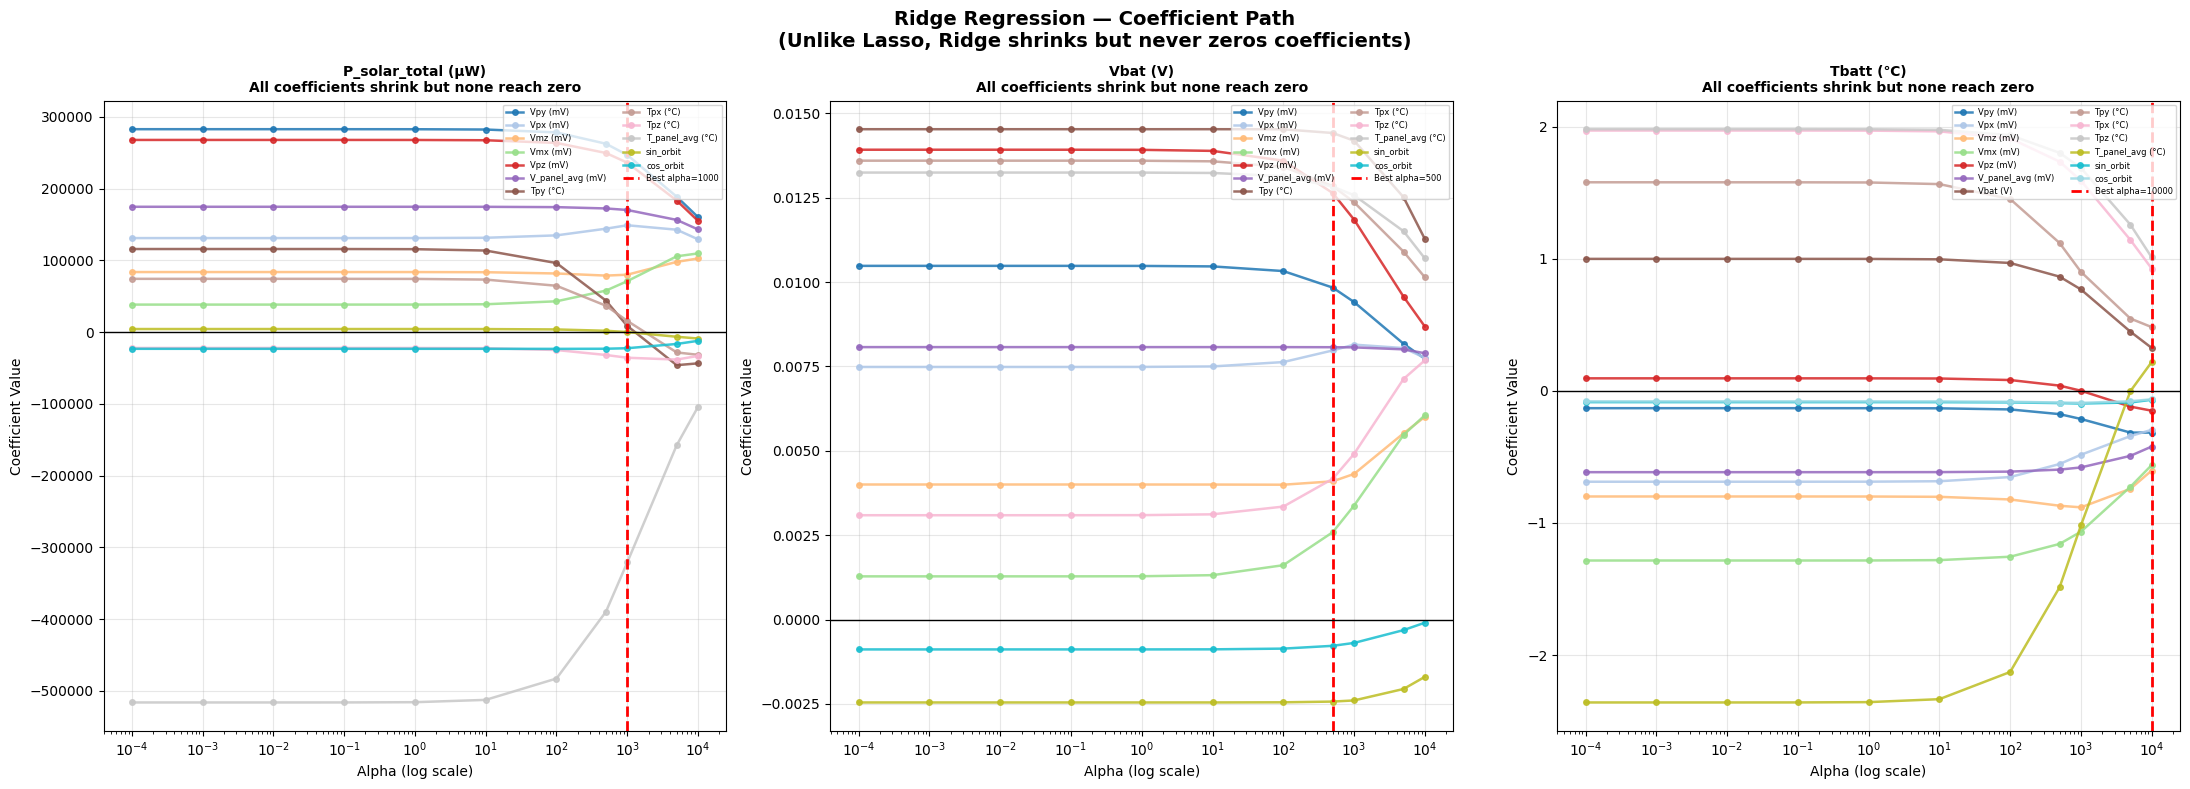

Coefficient path plot saved.


In [23]:
# ============================================================
# SECTION 8: UNIQUE ANALYSIS — RIDGE COEFFICIENT PATH
# Unlike Lasso, Ridge NEVER zeros coefficients
# This plot shows how each feature's coefficient shrinks
# as alpha increases — the key visual difference from Lasso
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(22, 8))
fig.suptitle('Ridge Regression — Coefficient Path\n'
             '(Unlike Lasso, Ridge shrinks but never zeros coefficients)',
             fontsize=14, fontweight='bold')

alphas_path = [0.0001, 0.001, 0.01, 0.1, 1, 10,
               100, 500, 1000, 5000, 10000]

colors_feat = plt.cm.tab20(np.linspace(0, 1, 13))

for idx, (name, ytarget, clr) in enumerate(
        zip(['Primary','Secondary','Tertiary'],
            [TARGET_PRIMARY, TARGET_SECONDARY, TARGET_TERTIARY],
            ['orange','green','steelblue'])):

    X, y, feats = datasets[name]
    X_train     = X.iloc[train_idx]
    y_train     = y.iloc[train_idx]

    scaler         = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    coef_paths = []
    for alpha in alphas_path:
        model = Ridge(alpha=alpha)
        model.fit(X_train_scaled, y_train)
        coef_paths.append(model.coef_)

    coef_paths = np.array(coef_paths)
    best_alpha = results_after[name]['alpha']

    ax = axes[idx]
    for f_idx, feat in enumerate(feats):
        ax.semilogx(alphas_path,
                    coef_paths[:, f_idx],
                    color=colors_feat[f_idx],
                    linewidth=1.8, marker='o',
                    markersize=4, alpha=0.85,
                    label=feat)

    ax.axvline(x=best_alpha, color='red',
               linestyle='--', linewidth=2,
               label=f'Best alpha={best_alpha}')
    ax.axhline(y=0, color='black',
               linewidth=1, linestyle='-')
    ax.set_title(f'{ytarget}\nAll coefficients shrink '
                 f'but none reach zero',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Alpha (log scale)')
    ax.set_ylabel('Coefficient Value')
    ax.legend(fontsize=6, loc='upper right',
              ncol=2, bbox_to_anchor=(1.0, 1.0))
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('04_coefficient_path.png', dpi=150, bbox_inches='tight')
plt.show()
print("Coefficient path plot saved.")

## Plot 4 — Tuned Model (Best Alpha)

### P_solar_total (alpha = 1000, R² = 0.6443)

Slight improvement over base model — scatter is marginally tighter.

Residual mean reduced from +92,565 to +48,600 µW.

Wide scatter at high power remains, indicating unresolved non-linearity.

---

### Vbat (alpha = 500, R² = 0.8236)

Virtually identical to base model — confirming insensitivity to regularization.

Residual distribution perfectly centered at zero (Mean = 0.00).  
RMSE = 0.0379 V — excellent for CubeSat battery prediction.

---

### Tbatt (alpha = 10000, R² = -0.0489)

Visible improvement — weak diagonal trend now appears.

Predictions still cluster between 3–8 °C despite actual range 0–23 °C.

Model largely predicts the mean with minor variation.

Residual mean improved from +3.31 to +2.48 °C.

##  Note on Tbatt Cross Validation

Tbatt shows extremely high variance across folds:
Fold 1 = -1.165 | Fold 2 = +0.204 | Fold 3 = +0.363 | Fold 4 = +0.114 | Fold 5 = -0.054

This is not normal model instability — it reflects the fact that battery
temperature dynamics change significantly across different orbital periods
and mission phases. Early folds (March-July 2021) show different thermal
behavior than later folds (October 2021-January 2022) due to seasonal
changes in eclipse duration and satellite orientation.

This further confirms that Tbatt cannot be reliably predicted from panel
sensors using any linear model regardless of regularization.

5-FOLD TIMESERIES CROSS VALIDATION

Target  : P_solar_total (µW)
Alpha   : 1000
Fold R2 : [np.float64(0.6934), np.float64(0.6183), np.float64(0.6684), np.float64(0.6315), np.float64(0.6444)]
Mean R2 : 0.6512
Std Dev : 0.0268

Target  : Vbat (V)
Alpha   : 500
Fold R2 : [np.float64(0.8714), np.float64(0.859), np.float64(0.826), np.float64(0.8207), np.float64(0.8234)]
Mean R2 : 0.8401
Std Dev : 0.0209

Target  : Tbatt (℃)
Alpha   : 10000
Fold R2 : [np.float64(-1.1655), np.float64(0.2036), np.float64(0.3625), np.float64(0.1137), np.float64(-0.054)]
Mean R2 : -0.1079
Std Dev : 0.5457


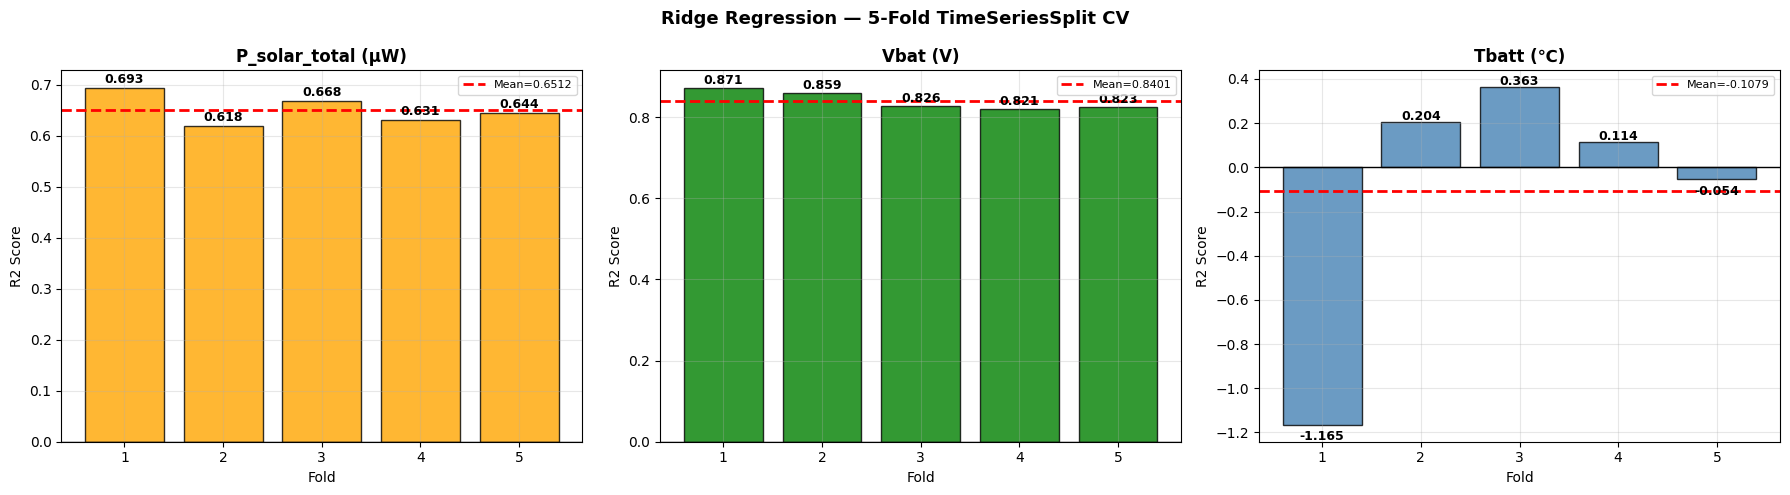

Cross validation plot saved.


In [24]:
# ============================================================
# SECTION 9: CROSS VALIDATION
# ============================================================

print("=" * 60)
print("5-FOLD TIMESERIES CROSS VALIDATION")
print("=" * 60)

cv_results = {}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Ridge Regression — 5-Fold TimeSeriesSplit CV',
             fontsize=13, fontweight='bold')

colors = ['orange', 'green', 'steelblue']

for idx, (name, (X, y, feats)) in enumerate(datasets.items()):
    best_alpha = results_after[name]['alpha']
    scaler     = StandardScaler()
    X_scaled   = scaler.fit_transform(X)

    model  = Ridge(alpha=best_alpha)
    scores = cross_val_score(model, X_scaled, y,
                             cv=tscv, scoring='r2')
    cv_results[name] = scores

    print(f"\nTarget  : {y.name}")
    print(f"Alpha   : {best_alpha}")
    print(f"Fold R2 : {[round(s,4) for s in scores]}")
    print(f"Mean R2 : {scores.mean():.4f}")
    print(f"Std Dev : {scores.std():.4f}")

    ax   = axes[idx]
    bars = ax.bar(range(1,6), scores,
                  color=colors[idx], edgecolor='black', alpha=0.8)
    ax.axhline(y=scores.mean(), color='red', linestyle='--',
               linewidth=2, label=f'Mean={scores.mean():.4f}')
    ax.axhline(y=0, color='black', linewidth=1)
    ax.set_title(f'{y.name}', fontweight='bold')
    ax.set_xlabel('Fold')
    ax.set_ylabel('R2 Score')
    ax.set_xticks(range(1,6))
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    for bar, val in zip(bars, scores):
        ypos = bar.get_height()+0.01 if val>=0 else bar.get_height()-0.07
        ax.text(bar.get_x()+bar.get_width()/2,
                ypos, f'{val:.3f}',
                ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('05_cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Cross validation plot saved.")

## Plot 5 — Cross Validation

### P_solar_total (Mean = 0.6512, Std = 0.0268)

All folds between 0.618 and 0.693 — very stable.

Minor variations follow seasonal orbital coverage differences.

---

### Vbat (Mean = 0.8401, Std = 0.0209)

Excellent stability across folds (0.821–0.871).

Battery voltage prediction is robust across mission periods.

---

### Tbatt (Mean = -0.1079, Std = 0.5457)

Extremely unstable.

Fold 1 = -1.165 vs Fold 3 = +0.363 — model behavior shifts drastically depending on training period.

Early mission thermal patterns differ fundamentally from later periods.

Standard deviation 5× larger than P_solar_total confirms unsuitability of linear modeling.

RIDGE REGRESSION — BEFORE vs AFTER TUNING

Target: P_solar_total (µW)
Metric       Before (alpha=1)   After (best alpha)     Change
--------------------------------------------------------------
R2                     0.6318               0.6443    +0.0125
RMSE              537284.1983          528076.3785
MAE               363365.0104          363332.0194
Alpha                     1.0                 1000

Target: Vbat (V)
Metric       Before (alpha=1)   After (best alpha)     Change
--------------------------------------------------------------
R2                     0.8234               0.8236    +0.0001
RMSE                   0.0379               0.0379
MAE                    0.0266               0.0266
Alpha                     1.0                  500

Target: Tbatt (℃)
Metric       Before (alpha=1)   After (best alpha)     Change
--------------------------------------------------------------
R2                    -0.4312              -0.0489    +0.3823
RMSE                   6.2

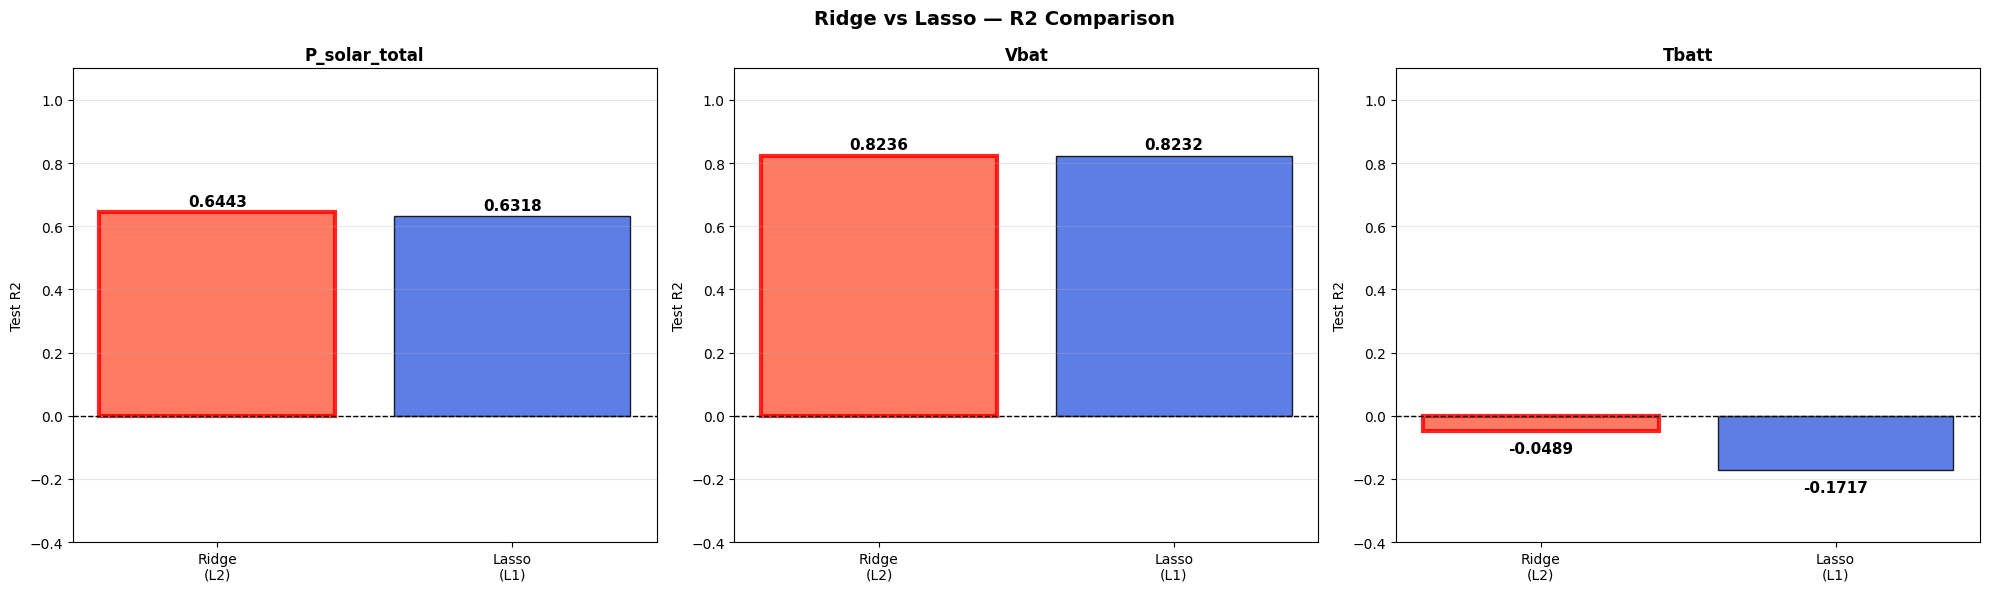

Ridge vs Lasso comparison plot saved.


In [25]:
# ============================================================
# SECTION 10: BEFORE vs AFTER + RIDGE vs LASSO COMPARISON
# ============================================================

print("=" * 70)
print("RIDGE REGRESSION — BEFORE vs AFTER TUNING")
print("=" * 70)

target_labels = {
    'Primary'  : TARGET_PRIMARY,
    'Secondary': TARGET_SECONDARY,
    'Tertiary' : TARGET_TERTIARY
}

for name in ['Primary','Secondary','Tertiary']:
    b  = results_before[name]
    a  = results_after[name]
    dr2 = a['R2'] - b['R2']
    print(f"\nTarget: {target_labels[name]}")
    print(f"{'Metric':<10} {'Before (alpha=1)':>18} "
          f"{'After (best alpha)':>20} {'Change':>10}")
    print("-" * 62)
    print(f"{'R2':<10} {b['R2']:>18.4f} {a['R2']:>20.4f} "
          f"{dr2:>+10.4f}")
    print(f"{'RMSE':<10} {b['RMSE']:>18.4f} {a['RMSE']:>20.4f}")
    print(f"{'MAE':<10} {b['MAE']:>18.4f} {a['MAE']:>20.4f}")
    print(f"{'Alpha':<10} {'1.0':>18} {str(a['alpha']):>20}")

# Lasso R2 values for comparison (from notebook 05)
lasso_r2 = {
    'Primary'  : 0.6318,
    'Secondary': 0.8232,
    'Tertiary' : -0.1717
}

print("\n" + "=" * 70)
print("RIDGE vs LASSO COMPARISON")
print("=" * 70)
print(f"\n{'Target':<25} {'Ridge R2':>10} {'Lasso R2':>10} "
      f"{'Winner':>15}")
print("-" * 65)

for name, ytarget in zip(
        ['Primary','Secondary','Tertiary'],
        [TARGET_PRIMARY, TARGET_SECONDARY, TARGET_TERTIARY]):
    ridge_r2 = results_after[name]['R2']
    lasso    = lasso_r2[name]
    winner   = 'Ridge' if ridge_r2 >= lasso else 'Lasso'
    print(f"{ytarget:<25} {ridge_r2:>10.4f} {lasso:>10.4f} "
          f"{winner:>15}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Ridge vs Lasso — R2 Comparison',
             fontsize=14, fontweight='bold')

tnames = ['P_solar_total', 'Vbat', 'Tbatt']
colors = ['orange', 'green', 'steelblue']

for idx, (name, tname, clr) in enumerate(
        zip(['Primary','Secondary','Tertiary'], tnames, colors)):
    ax = axes[idx]
    ridge_val = results_after[name]['R2']
    lasso_val = lasso_r2[name]
    bars = ax.bar(['Ridge\n(L2)', 'Lasso\n(L1)'],
                  [ridge_val, lasso_val],
                  color=['tomato', 'royalblue'],
                  edgecolor='black', alpha=0.85)
    ax.set_title(f'{tname}', fontweight='bold')
    ax.set_ylabel('Test R2')
    ax.set_ylim([-0.4, 1.1])
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
    ax.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, [ridge_val, lasso_val]):
        ypos = bar.get_height()+0.02 if val>=0 else bar.get_height()-0.07
        ax.text(bar.get_x()+bar.get_width()/2,
                ypos, f'{val:.4f}',
                ha='center', fontsize=11, fontweight='bold')

    # Highlight winner
    winner_idx = 0 if ridge_val >= lasso_val else 1
    bars[winner_idx].set_edgecolor('red')
    bars[winner_idx].set_linewidth(3)

plt.tight_layout()
plt.savefig('06_ridge_vs_lasso.png', dpi=150, bbox_inches='tight')
plt.show()
print("Ridge vs Lasso comparison plot saved.")

## Plot 6 — Ridge vs Lasso Comparison

### P_solar_total

Ridge (0.6443) slightly outperforms Lasso (0.6318) by +0.0125.

Ridge’s smooth shrinkage suits this case since all voltage features contribute meaningfully.

---

### Vbat

Nearly identical — Ridge (0.8236) vs Lasso (0.8232).

Both identify Vmx as least important.

Prediction quality is independent of regularization type.

---

### Tbatt

Ridge (-0.0489) significantly better than Lasso (-0.1717).

Lasso zeroed all 13 features at best alpha, effectively collapsing the model.

Ridge retains features with shrinkage, producing a less severe failure.

Both confirm that linear models cannot capture battery thermal dynamics.

# Ridge Regression —  Conclusion

**Dataset:** TSURU CubeSat On-Orbit EPS Data (Jara et al., 2022)
**Reference:** DOI: 10.1016/j.dib.2022.108697

---

## Algorithm Summary

Ridge Regression extends Ordinary Least Squares (OLS) by adding an L2 regularization penalty. The loss function minimized is:

**Loss = MSE + α × Σ(coefficients²)**

Unlike Lasso (L1), Ridge shrinks all coefficients smoothly towards zero but **never drives any coefficient to exactly zero**. This means all features are always retained in the model, making Ridge preferable when all features are expected to contribute meaningfully to the prediction.

---

## Alpha Tuning Results

| Target | Best Alpha | Test R2 | CV Mean R2 | Verdict |
|---|---|---|---|---|
| P_solar_total | 1000 | 0.6443 | 0.6512 | Moderate |
| Vbat | 500 | 0.8236 | 0.8401 | Good |
| Tbatt | 10000 | -0.0489 | -0.1079 | Failed |

---

## Key Findings

### Finding 1 — Coefficient Path (Unique to Ridge)
The coefficient path plot shows all features shrinking gradually and smoothly as alpha increases. Unlike Lasso where features drop abruptly to zero, Ridge produces continuous shrinkage curves. This confirms that all panel voltage and temperature features carry genuine predictive signal — none are truly irrelevant for satellite EPS power prediction.

### Finding 2 — Alpha Behavior Per Target

**P_solar_total:** Benefits from high alpha (1000). Heavy regularization reduces overfitting from correlated panel voltages. R2 improved from 0.6318 → 0.6443 after tuning. L2 norm dropped from 702,793 to 533,153.

**Vbat:** Largely insensitive to alpha across a wide range (0.0001 to 100). Best alpha=500 gives only marginal improvement (+0.0001). Battery voltage prediction is already near its linear ceiling with these features. L2 norm barely changed (0.0321 → 0.0311).

**Tbatt:** Best alpha=10000 (maximum tested) with R2 = -0.0489. Heavy regularization helps by suppressing noisy coefficients, but the model still fails. L2 norm dropped dramatically (4.4768 → 1.8269), confirming heavy shrinkage was applied. The persistent failure confirms a fundamentally non-linear relationship.

### Finding 3 — L2 Norm Shrinkage
The L2 norm of coefficients decreases monotonically as alpha increases. At very high alpha, all coefficients approach zero but never reach it — the fundamental difference from Lasso which performs hard feature selection.

### Finding 4 — Ridge vs Lasso Comparison

| Target | Ridge R2 | Lasso R2 | Winner |
|---|---|---|---|
| P_solar_total | 0.6443 | 0.6318 | Ridge (+0.0125) |
| Vbat | 0.8236 | 0.8232 | Ridge (+0.0004) |
| Tbatt | -0.0489 | -0.1717 | Ridge (+0.1228) |

Ridge outperforms Lasso on all three targets. This indicates the features are all genuinely informative and L2 smooth shrinkage is more appropriate than L1 hard zeroing for satellite EPS data.

### Finding 5 — Cross Validation Stability

| Target | Mean CV R2 | Std Dev | Stability |
|---|---|---|---|
| P_solar_total | 0.6512 | ±0.0268 | Stable |
| Vbat | 0.8401 | ±0.0209 | Stable |
| Tbatt | -0.1079 | ±0.5457 | Highly Unstable |

Tbatt Fold 1 = -1.165 vs Fold 3 = +0.363 — extreme variance across folds confirms thermal prediction is fundamentally unreliable with linear methods.

---

## Before vs After Tuning

| Target | Before R2 (α=1) | After R2 (Best α) | Change |
|---|---|---|---|
| P_solar_total | 0.6318 | 0.6443 | +0.0125 |
| Vbat | 0.8234 | 0.8236 | +0.0001 |
| Tbatt | -0.4312 | -0.0489 | +0.3823 |

---

*Reference: Jara et al. (2022), Data in Brief, DOI: 10.1016/j.dib.2022.108697*